# Homework 1 - Part 1: KNN Classifier
### Burak Kuruçay - 210104004049
---

This section implements a KNN classifier from scratch using Euclidean distance with K=3.
The model is evaluated with 6-fold cross validation.
Performance is reported using confusion matrices, ROC curves, and runtime analysis.

## Code:

### Import the necessary modules

In [12]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sys.path.append(os.path.abspath("../src"))

from knn_classifier import KNNClassifier
from distance import euclidean_distance

### Load the dataset
Load the data and show the number of lines, features and name of the classes.

In [13]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class names:", data.target_names)

X shape: (569, 30)
y shape: (569,)
Class names: ['malignant' 'benign']


### Monitor the data
Just for see the dataset loaded.

In [14]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Train By 6-Fold Cross Validation

In [15]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

fold_results = []

overall_start_time = time.time()

for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = KNNClassifier(k=3, distance_func=euclidean_distance)

    fold_start_time = time.time()
    model.fit(X_train, y_train)

    train_probabilities = model.predict_proba(X_train)[:, 1]
    test_probabilities = model.predict_proba(X_test)[:, 1]
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    fold_end_time = time.time()

    train_fpr, train_tpr, _ = roc_curve(y_train, train_probabilities)
    test_fpr, test_tpr, _ = roc_curve(y_test, test_probabilities)

    fold_results.append({
        "fold": fold_idx,
        "train_accuracy": accuracy_score(y_train, train_predictions),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "train_precision": precision_score(y_train, train_predictions, zero_division=0),
        "test_precision": precision_score(y_test, test_predictions, zero_division=0),
        "train_recall": recall_score(y_train, train_predictions, zero_division=0),
        "test_recall": recall_score(y_test, test_predictions, zero_division=0),
        "f1_score": f1_score(y_test, test_predictions, zero_division=0),
        "train_auc": roc_auc_score(y_train, train_probabilities),
        "test_auc": roc_auc_score(y_test, test_probabilities),
        "train_fpr": train_fpr,
        "train_tpr": train_tpr,
        "test_fpr": test_fpr,
        "test_tpr": test_tpr,
        "train_confusion_matrix": confusion_matrix(y_train, train_predictions),
        "test_confusion_matrix": confusion_matrix(y_test, test_predictions),
        "runtime_seconds": fold_end_time - fold_start_time
    })

overall_end_time = time.time()
mean_runtime = np.mean([r["runtime_seconds"] for r in fold_results])
total_runtime = overall_end_time - overall_start_time

## Results:

### Test Fold Confusion Matrices

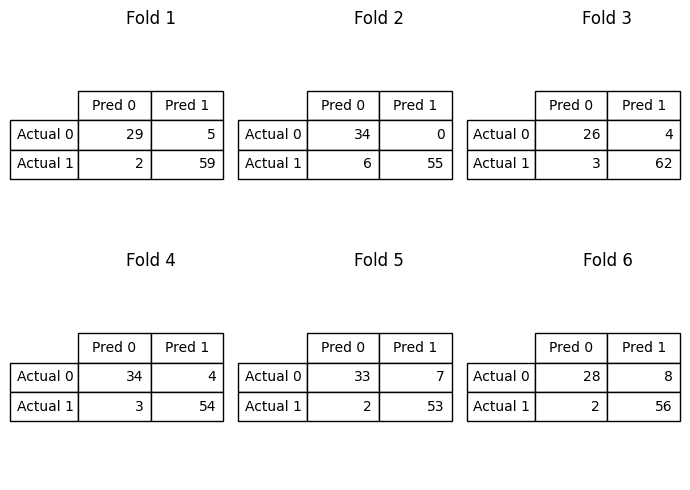

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(7, 5))

axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax = axes[i]
    ax.axis('off')

    cm = result["test_confusion_matrix"]

    table_data = [
        [cm[0][0], cm[0][1]],
        [cm[1][0], cm[1][1]]
    ]

    row_labels = ["Actual 0", "Actual 1"]
    col_labels = ["Pred 0", "Pred 1"]

    table = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc='center'
    )

    table.scale(1, 1.5)
    ax.set_title(f"Fold {result['fold']}")

plt.tight_layout()
plt.show()

### Classification Metrics

,Fold,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,F1 Score,Train AUC,Test AUC
0,1,0.9515,0.9263,0.9417,0.9219,0.9831,0.9672,0.9440,0.9937,0.9766
1,2,0.9494,0.9368,0.9474,1.0000,0.9730,0.9016,0.9483,0.9933,0.9971
2,3,0.9536,0.9263,0.9441,0.9394,0.9829,0.9538,0.9466,0.9935,0.9349
3,4,0.9557,0.9263,0.9544,0.9310,0.9767,0.9474,0.9391,0.9946,0.9557
4,5,0.9557,0.9053,0.9518,0.8833,0.9801,0.9636,0.9217,0.9945,0.9509
5,6,0.9600,0.8936,0.9575,0.8750,0.9799,0.9655,0.9180,0.9953,0.9229


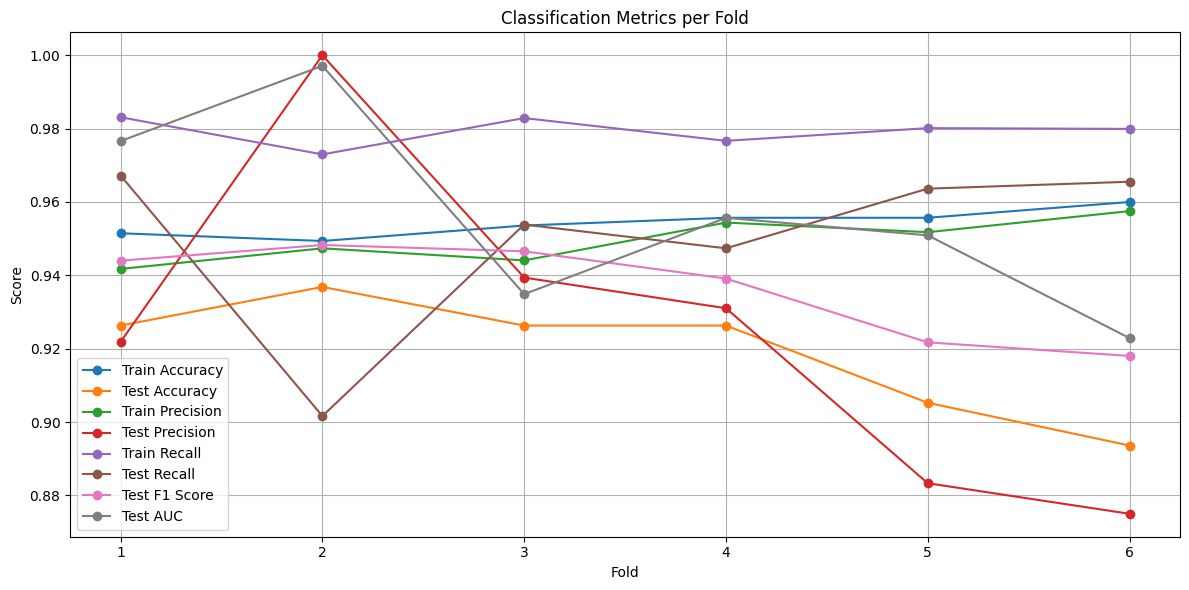

In [17]:
metric_rows = []

for result in fold_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Train Accuracy": result["train_accuracy"],
        "Test Accuracy": result["test_accuracy"],
        "Train Precision": result["train_precision"],
        "Test Precision": result["test_precision"],
        "Train Recall": result["train_recall"],
        "Test Recall": result["test_recall"],
        "F1 Score": result["f1_score"],
        "Train AUC": result["train_auc"],
        "Test AUC": result["test_auc"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in fold_results]
train_accs = [r["train_accuracy"] for r in fold_results]
test_accs = [r["test_accuracy"] for r in fold_results]
train_precisions = [r["train_precision"] for r in fold_results]
test_precisions = [r["test_precision"] for r in fold_results]
train_recalls = [r["train_recall"] for r in fold_results]
test_recalls = [r["test_recall"] for r in fold_results]
f1_scores = [r["f1_score"] for r in fold_results]
test_aucs = [r["test_auc"] for r in fold_results]

plt.figure(figsize=(12, 6))
plt.plot(folds, train_accs, marker='o', label="Train Accuracy")
plt.plot(folds, test_accs, marker='o', label="Test Accuracy")
plt.plot(folds, train_precisions, marker='o', label="Train Precision")
plt.plot(folds, test_precisions, marker='o', label="Test Precision")
plt.plot(folds, train_recalls, marker='o', label="Train Recall")
plt.plot(folds, test_recalls, marker='o', label="Test Recall")
plt.plot(folds, f1_scores, marker='o', label="Test F1 Score")
plt.plot(folds, test_aucs, marker='o', label="Test AUC")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Classification Metrics per Fold")
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Runtime Performance
The runtime of the KNN classifier was measured for each fold during the 6-fold cross validation process. <br>
Both per-fold runtimes and the total cross-validation runtime are reported below.

In [18]:
runtime_rows = []

for result in fold_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        mean_runtime,
        total_runtime
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)

,Fold,Runtime (seconds)
0,1,2.8490
1,2,2.8306
2,3,2.8379
3,4,2.8878
4,5,2.8826
5,6,2.8110


,Metric,Runtime (seconds)
0,Average runtime per fold,2.8498
1,Total 6-fold CV runtime,17.1412


### Selected Fold Performance Results
Select the fold whose test accuracy is closest to the mean test accuracy across all folds.

In [19]:
# Select the fold whose test accuracy is closest to the mean test accuracy across all folds
mean_test_acc = np.mean([r["test_accuracy"] for r in fold_results])

selected_fold = min(
    fold_results,
    key=lambda r: abs(r["test_accuracy"] - mean_test_acc)
)

,Metric,Value
0,Train Accuracy,0.9515
1,Test Accuracy,0.9263
2,Train Precision,0.9417
3,Test Precision,0.9219
4,Train Recall,0.9831
5,Test Recall,0.9672
6,Test F1 Score,0.9440
7,Train AUC,0.9937
8,Test AUC,0.9766


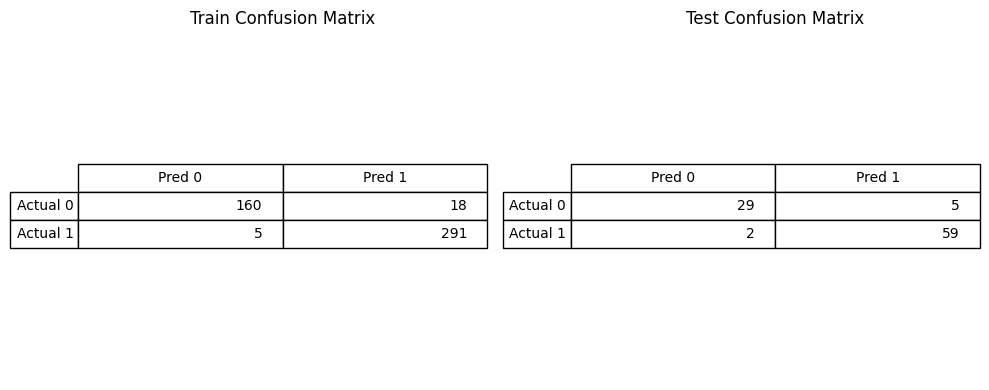

In [20]:
df_selected_performance = pd.DataFrame({
    "Metric": [
        "Train Accuracy", "Test Accuracy",
        "Train Precision", "Test Precision",
        "Train Recall", "Test Recall",
        "Test F1 Score",
        "Train AUC", "Test AUC"
    ],
    "Value": [
        selected_fold["train_accuracy"],
        selected_fold["test_accuracy"],
        selected_fold["train_precision"],
        selected_fold["test_precision"],
        selected_fold["train_recall"],
        selected_fold["test_recall"],
        selected_fold["f1_score"],
        selected_fold["train_auc"],
        selected_fold["test_auc"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, matrix_key, title in [
    (axes[0], "train_confusion_matrix", "Train Confusion Matrix"),
    (axes[1], "test_confusion_matrix", "Test Confusion Matrix")
]:
    ax.axis("off")
    cm = selected_fold[matrix_key]
    table = ax.table(
        cellText=[[cm[0][0], cm[0][1]], [cm[1][0], cm[1][1]]],
        rowLabels=["Actual 0", "Actual 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center"
    )
    table.scale(1, 1.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Selected Fold ROC Curve
ROC is drawn only for the selected fold. KNN does not learn a separate probability model here; the positive-class score is estimated from the fraction of positive labels among the `k=3` nearest neighbors. That score is thresholded from high to low to trace TPR versus FPR.

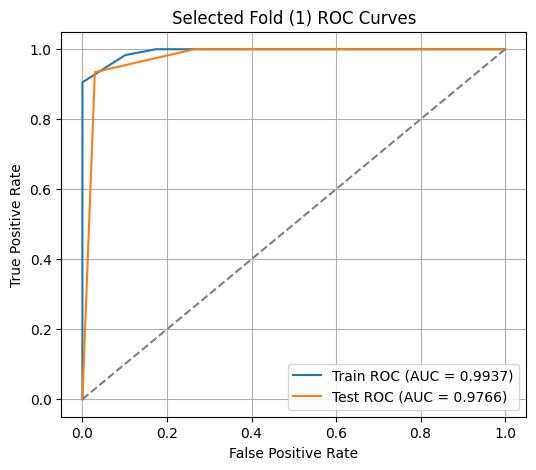

In [21]:
plt.figure(figsize=(6, 5))
plt.plot(
    selected_fold["train_fpr"],
    selected_fold["train_tpr"],
    label=f"Train ROC (AUC = {selected_fold['train_auc']:.4f})"
)
plt.plot(
    selected_fold["test_fpr"],
    selected_fold["test_tpr"],
    label=f"Test ROC (AUC = {selected_fold['test_auc']:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Selected Fold ({selected_fold['fold']}) ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

## Comments:
- The KNN classifier shows a small but visible gap between training and test accuracy across folds. This suggests that the model captures the local structure of the training set well, while its performance on unseen samples is slightly more sensitive to the composition of each neighborhood.
- Test recall remains relatively high, whereas test precision decreases in some folds. This is a reasonable pattern for KNN, because class decisions are directly determined by nearby labeled observations; when borderline cases are present, the local vote may produce more positive predictions and therefore more false positives.
- The ROC analysis is based on neighbor vote ratios rather than on a separately calibrated probability model. For this reason, the AUC values should be interpreted as evidence of ranking quality derived from local class density, not as evidence of probability calibration.
- The last folds show a mild decline in test accuracy and test AUC compared with the earlier folds. This result may indicate that KNN is somewhat sensitive to fold-specific sample distribution, which is expected for an instance-based classifier.
- The runtime is clearly higher than that of the SVM-based model. This behavior is consistent with the lazy learning nature of KNN, where much of the computational burden appears during prediction because distances to training observations must be evaluated for each test sample.
